# S&P 500 Monthly Average

Uses the same project data-fetch pattern as your other notebooks via `get_data_auto`.

In [46]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

_ROOT = Path.cwd() if (Path.cwd() / "Data_Handling.py").exists() else Path.cwd() / "Mario"
if not (_ROOT / "Data_Handling.py").exists():
    _ROOT = Path.cwd().parent if (Path.cwd().parent / "Data_Handling.py").exists() else Path.cwd().parent / "Mario"
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from Data_Handling import get_data_auto

In [47]:
symbol = "^GSPC"
start_date = "2015-01-01"
end_date = pd.Timestamp.today().strftime("%Y-%m-%d")
timeframe_unit = "Day"
multiplier = 1

data = get_data_auto(
    symbol,
    start=start_date,
    end=end_date,
    timeframe_unit=timeframe_unit,
    multiplier=multiplier,
)


In [48]:
close = data['Close'].dropna().copy()

monthly_bounds = close.groupby([close.index.year, close.index.month]).agg(['first', 'last'])
monthly_bounds['Monthly_Change'] = monthly_bounds['last'] - monthly_bounds['first']

avg_change_by_month = monthly_bounds['Monthly_Change'].groupby(level=1).mean().reindex(range(1, 13))
obs_count_by_month = monthly_bounds['Monthly_Change'].groupby(level=1).size().reindex(range(1, 13), fill_value=0)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
avg_change_by_month.index = month_names
obs_count_by_month.index = month_names

avg_change_by_month = avg_change_by_month.fillna(0)
pd.DataFrame({'Avg_Change': avg_change_by_month, 'Obs_Count': obs_count_by_month})

,Avg_Change,Obs_Count
Jan,42.962453,12
Feb,-33.018351,12
Mar,-44.469961,12
Apr,33.335917,12
May,63.394465,11
Jun,56.812744,11
Jul,100.135498,11
Aug,42.099953,11
Sep,-31.686379,11
Oct,37.568149,11


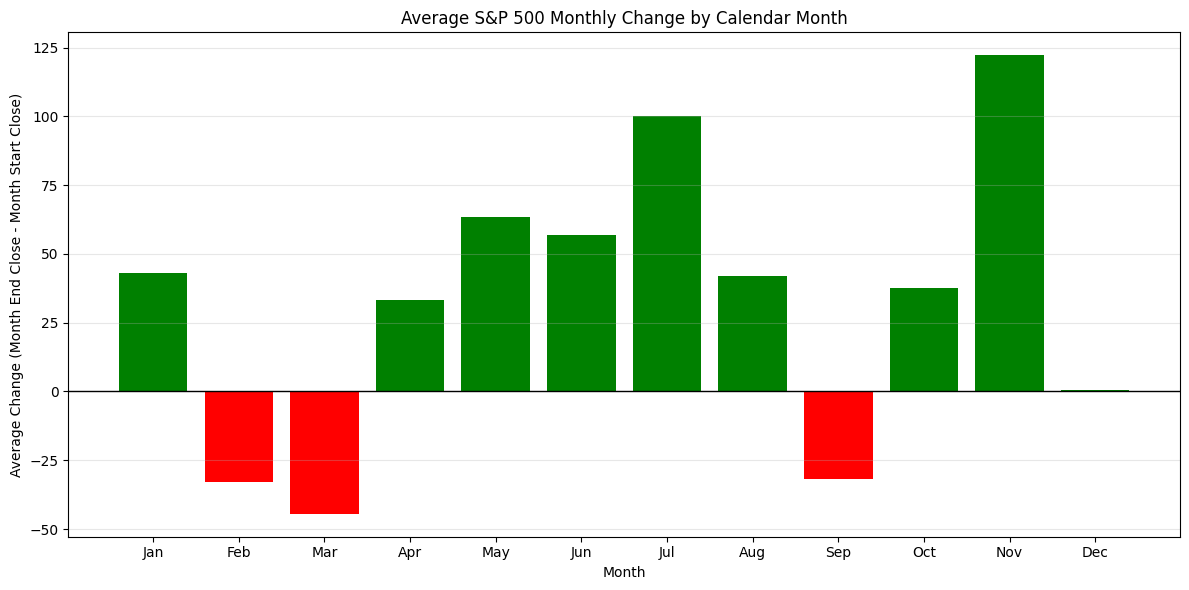

In [49]:
bar_colors = ['green' if v >= 0 else 'red' for v in avg_change_by_month.values]

plt.figure(figsize=(12, 6))
plt.bar(avg_change_by_month.index, avg_change_by_month.values, color=bar_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('Average S&P 500 Monthly Change by Calendar Month')
plt.xlabel('Month')
plt.ylabel('Average Change (Month End Close - Month Start Close)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Last 16 Years: Average Daily P/L by Day of Month (1-25)

In [50]:
end_date_16y = "01-01-2026"
start_date_16y = "01-01-2006"

data_16y = get_data_auto(
    'SPY',
    start=start_date_16y,
    end=end_date_16y,
    timeframe_unit='Day',
    multiplier=1,
)

daily_1_25 = data_16y.loc[data_16y.index.day <= 25, ['Open', 'Close']].copy()
daily_1_25['Daily_PL'] = daily_1_25['Close'] - daily_1_25['Open']

avg_pl_by_day = daily_1_25.groupby(daily_1_25.index.day)['Daily_PL'].mean().reindex(range(1, 26))
obs_count_by_day = daily_1_25.groupby(daily_1_25.index.day).size().reindex(range(1, 26), fill_value=0)

avg_pl_by_day = avg_pl_by_day.fillna(0)
pd.DataFrame({'Avg_Daily_PL': avg_pl_by_day, 'Obs_Count': obs_count_by_day})

,Avg_Daily_PL,Obs_Count
timestamp,,
1,0.030909,154
2,0.401526,161
3,-0.174454,165
4,0.104771,154
5,0.139697,165
6,0.248268,168
7,-0.100371,167
8,0.145665,171
9,0.044120,170


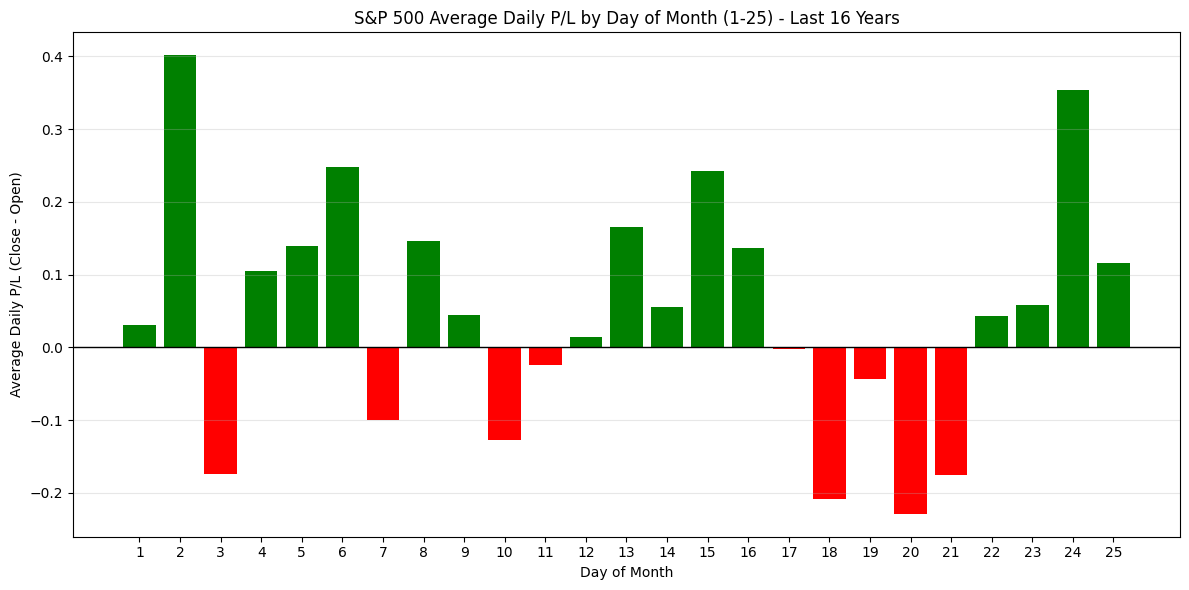

In [51]:
x_days = list(range(1, 26))
bar_colors = ['green' if v >= 0 else 'red' for v in avg_pl_by_day.values]

plt.figure(figsize=(12, 6))
plt.bar(x_days, avg_pl_by_day.values, color=bar_colors)
plt.axhline(0, color='black', linewidth=1)
plt.title('S&P 500 Average Daily P/L by Day of Month (1-25) - Last 16 Years')
plt.xlabel('Day of Month')
plt.ylabel('Average Daily P/L (Close - Open)')
plt.xticks(x_days)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()